//TODO: Gain of $K = U\text{pinv}(V)$ vs $UV^T [VV^T + R]^{-1}$

Trying to reproduce results from Mini Project Report

In [1]:
%cd /content
!rm -rf rainfall_kf

!git clone https://github.com/Felix-Schwer/rainfall_kf.git
%cd rainfall_kf

!pip install -e .

/content
Cloning into 'rainfall_kf'...
remote: Enumerating objects: 260, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 260 (delta 63), reused 74 (delta 33), pack-reused 145 (from 1)
Receiving objects: 100% (260/260), 106.51 MiB | 21.60 MiB/s, done.
Resolving deltas: 100% (99/99), done.
/content/rainfall_kf
Obtaining file:///content/rainfall_kf
  Preparing metadata (setup.py) ... done
  Running setup.py develop for rainfall_kf


In [6]:
import numpy as np

from rainfall_kf.enkf import EnsembleKalmanFilter
from rainfall_kf.examples.hbvedu_read import read_hbv_initial, read_hbv_inputs, read_hbv_params, read_hbv_qobs
from rainfall_kf.models.hbvedu import HBVObservation, HBVTransition

np.random.seed(1)

N_STATES = 5
N_OBS = 1
N_ENS = 100

Qassumed = np.diag([2, 2, 0.5, 0.5, 1e-40])**2
Rassumed = np.diag([0.5])**2

params = read_hbv_params()
inputs_k = read_hbv_inputs()
observations_k = read_hbv_qobs()

iv_values = np.loadtxt("/content/rainfall_kf/rainfall_kf/examples/HBV_EDU/IV.txt", dtype=float, usecols=(1,))
catchment_area = iv_values[0]
observations_mm_day = observations_k * (24 * 3600.0) / (catchment_area * 1000.0)

x0 = read_hbv_initial()
k_steps = inputs_k.shape[1]
times = np.arange(k_steps)

initial_ensemble = x0 + np.linalg.cholesky(Qassumed).T @ np.random.randn(N_STATES, N_ENS)

In [7]:
enkf = EnsembleKalmanFilter(
    TransitionEquation=lambda states, inputs: HBVTransition(states, inputs, params),
    ObservationEquation=lambda states: HBVObservation(states, params),
    Q=Qassumed,
    R=Rassumed,
    addGaussInputSig=np.array([0.2, 0., 0., 0.]),
    mulLognormInputSig=np.array([0., 0.2, 0., 0.])
)

result = enkf.run(initial_ensemble=initial_ensemble, times=times, inputs=inputs_k, observations=observations_mm_day)

Text(0.5, 0, 'Lags')

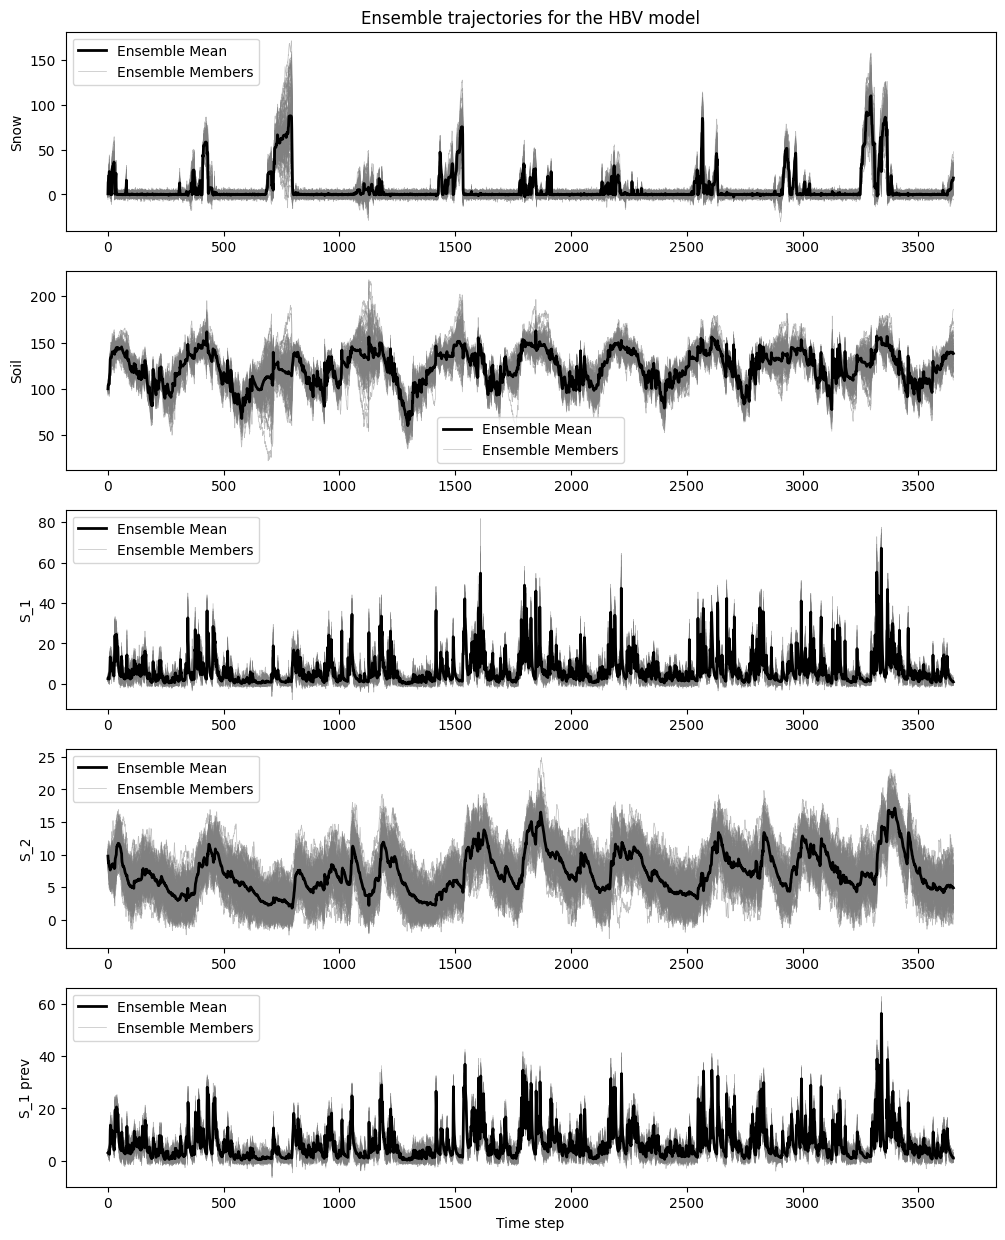

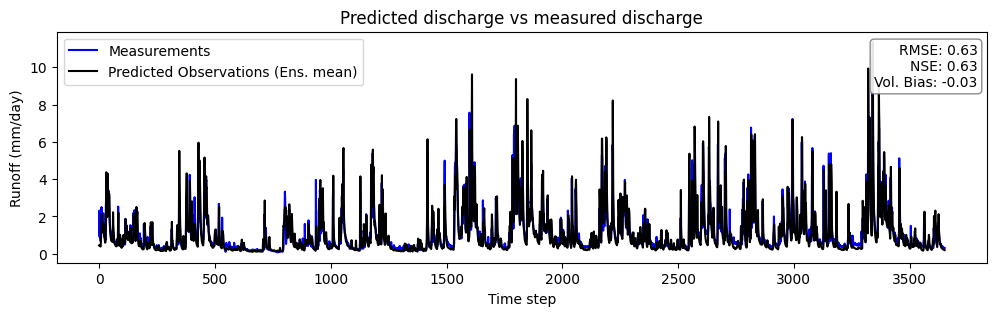

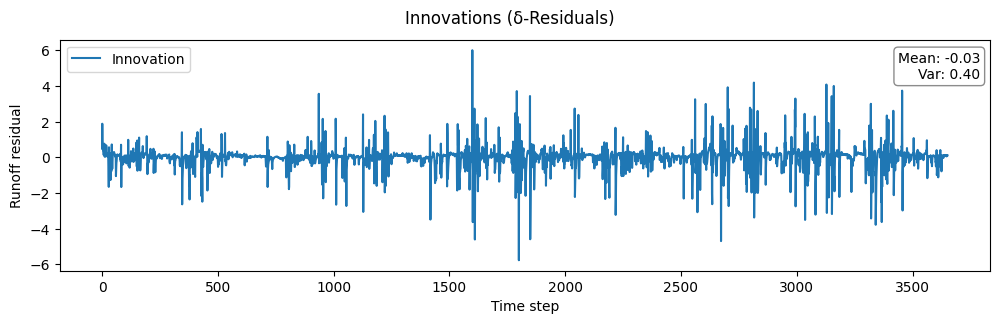

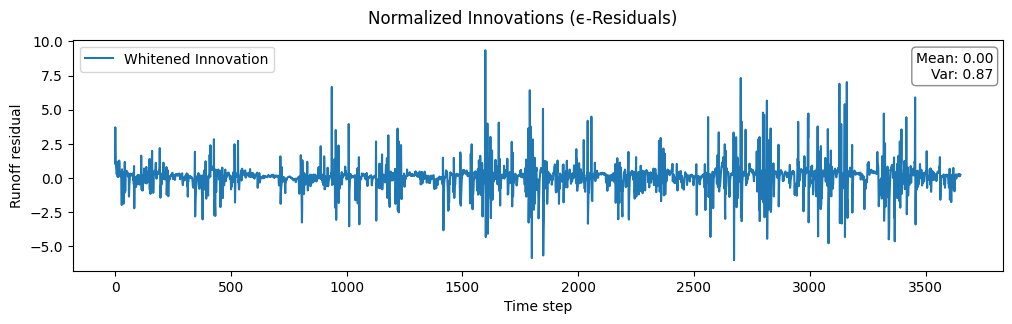

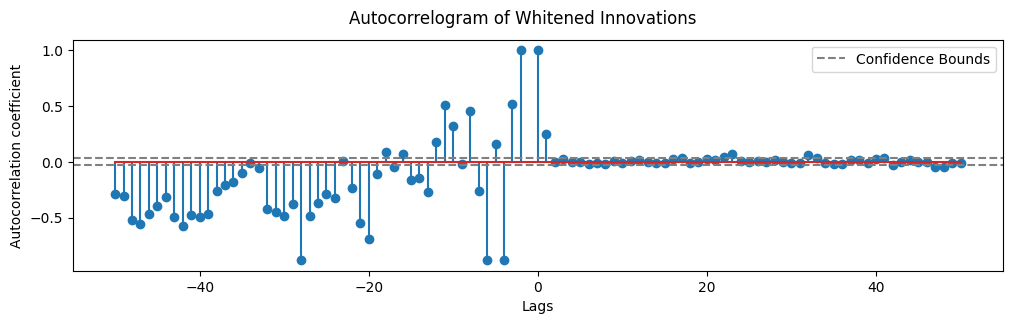

In [8]:
fig = result.plot_ensembles()
axes = fig.get_axes()
axes[0].set_title("Ensemble trajectories for the HBV model")
axes[0].set_ylabel("Snow")
axes[1].set_ylabel("Soil")
axes[2].set_ylabel("S_1")
axes[3].set_ylabel("S_2")
axes[4].set_ylabel("S_1 prev")
axes[4].set_xlabel("Time step")

fig = result.plot_observations()
ax = fig.get_axes()[0]
ax.set_title("Predicted discharge vs measured discharge")
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff (mm/day)")

fig = result.plot_innovations()
ax = fig.get_axes()[0]
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff residual")

fig = result.plot_whitened_innovations()
ax = fig.get_axes()[0]
ax.set_ylabel("Runoff residual")
ax.set_xlabel("Time step")

fig = result.plot_autocorrelogram(max_lag=50)
ax = fig.get_axes()[0]
ax.set_ylabel("Autocorrelation coefficient")
ax.set_xlabel("Lags")